In [ ]:
%pip install pandas scikit-learn numpy matplotlib seaborn geopandas plotly pyarrow

# Global Cluster Profile: Yearly Evolution

In this notebook, capitals are clustered singularly year-per-year, to track the climatic profile of each capital and evalute whether it changes or not in the considered period.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns
import geopandas as gpd
import plotly.graph_objects as go

from sklearn.decomposition import PCA

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

# Loading pre-processed data

We load the pre-processed climate history dataset, the mapping file that connects capital cities to their respective countries and the mapping files that connect capital cities to their respective latitude and longitude.

In [2]:
df = pd.read_parquet("cleaned_history.parquet")

with open("capital_to_country.json", "r") as f:
    capital_to_country = json.load(f)

with open("capital_to_lat.json", "r") as f:
    capital_to_lat = json.load(f)

with open("capital_to_lon.json", "r") as f:
    capital_to_lon = json.load(f)

print("Files successfully loaded!")

Files successfully loaded!


In [3]:
aggregation_per_anno = df.groupby(['capital','year']).agg(
    mean_temp=('temp_mean_c_approx','mean'),
    std_temp=('temp_mean_c_approx','std'),
    rain_total=('rain_mm','sum'),
    days_rain=('rain_mm', lambda x: (x>1.0).sum()),
    snow_total=('snow_mm','sum'),
    days_snow=('snow_mm', lambda x: (x>1.0).sum()),
    mean_daylight=('daylight_duration_s','mean'),
    mean_sunshine=('sunshine_duration_s','mean'),
).reset_index()

aggregation_per_anno.to_csv('aggregation_per_anno.csv', index=False)

# Clusters Re-Alingment

When running a clustering algorithm independently year by year, the labels assigned to the groups are completely arbitrary. This phenomenon, known as Label Switching, makes it impossible to track the temporal evolution of climates: simply following the trend of "Cluster 0" from 1995 to 2024 would mean comparing completely different meteorological profiles, resulting in a meaningless trajectory.

To coherently observe the evolution of capital cities within the clusters over the decades, this function implements a sequential alignment based on distance minimization:

1. **Baseline Definition**: The first year of the historical series acts as the absolute anchor. Its original labels define the baseline classification.

2. **Normalization and Distances**: Rather than recalculating standardization on a small sample of centroids, the algorithm extracts the already scaled centroids directly from the K-Means clustering step. The Euclidean distance matrix is then calculated between the pre-normalized centroids of the current year and those of the previous year. This ensures perfect mathematical consistency, as the distances are measured in the exact same vector space used to create the clusters originally.

3. **Global Optimization (Hungarian Algorithm)**: To determine which 1996 cluster corresponds to which 1995 cluster, we do not simply match the closest pairs one by one (a greedy approach), as this could create bottlenecks and forced, inaccurate pairings for the last remaining clusters. Instead, we use the linear_sum_assignment function (the Hungarian Algorithm), which evaluates the distance matrix and finds the optimal 1-to-1 mapping that minimizes the total global distance across all pairings.

4. **Remapping**: Once the optimal match is found, the current year's labels are translated and overwritten to maintain historical continuity with the past. Finally, the algorithm recalculates the unnormalized (raw) cluster means using these newly aligned labels, ensuring the final output remains perfectly interpretable (e.g., real Celsius degrees and millimeters of rain) for dashboards and human analysis.

In [4]:
def align_clusters_sequentially(df_clusters_dict, raw_means_dict, scaled_means_dict, years, features, n_clusters=5):
    """
    Aligns clusters sequentially across years: each year is aligned to the previous one
    based on the Euclidean distance between pre-NORMALIZED centroids.
    The first year defines the baseline reference labels.

    Args:
        df_clusters_dict (dict): Dictionary mapping years to DataFrames containing a 'cluster' column.
        raw_means_dict (dict): Dictionary mapping years to DataFrames of raw (unscaled) cluster centroids.
        scaled_means_dict (dict): Dictionary mapping years to DataFrames of scaled cluster centroids.
        years (list): Ordered list of years (e.g., [1995, 1996, ..., 2024]).
        features (list): List of feature names used for distance calculation.
        n_clusters (int): The fixed number of clusters expected each year.

    Returns:
        tuple: (aligned_clusters_dict, aligned_raw_means_dict)
    """

    aligned_clusters = {}
    aligned_raw_means = {}
    aligned_scaled_means = {}

    # The first year remains unchanged and acts as the absolute baseline
    aligned_clusters[years[0]] = df_clusters_dict[years[0]].copy()
    aligned_raw_means[years[0]] = raw_means_dict[years[0]].copy()
    aligned_scaled_means[years[0]] = scaled_means_dict[years[0]].copy()

    print("=" * 80)
    print("CLEAN SEQUENTIAL CLUSTER ALIGNMENT")
    print("=" * 80)
    print(f"\n{years[0]}: Initial Baseline (No remapping)")

    # Iterate through subsequent years to align them sequentially
    for i in range(1, len(years)):
        prev_year = years[i-1]
        curr_year = years[i]

        # 1. Extract SCALED centroids (the previous year's centroids are already aligned)
        prev_centroids_scaled = aligned_scaled_means[prev_year][features].values
        curr_centroids_scaled = scaled_means_dict[curr_year][features].values

        # Enforce fixed cluster count to ensure distance matrix is square (N x N)
        assert len(prev_centroids_scaled) == n_clusters, f"Expected {n_clusters} clusters, found {len(prev_centroids_scaled)}"
        assert len(curr_centroids_scaled) == n_clusters, f"Expected {n_clusters} clusters, found {len(curr_centroids_scaled)}"

        # 2. Calculate the Euclidean distance matrix directly on the scaled centroids generated by K-Means
        # Rows = current clusters, Columns = previous clusters
        distances = cdist(curr_centroids_scaled, prev_centroids_scaled, metric='euclidean')

        # 3. Apply the Hungarian algorithm to find the optimal 1-to-1 global assignment
        row_ind, col_ind = linear_sum_assignment(distances)

        # Create a mapping dictionary: {current_cluster_id: previous_cluster_id}
        mapping = {curr_cluster: prev_cluster for curr_cluster, prev_cluster in zip(row_ind, col_ind)}

        # 4. Apply the mapping to the main DataFrame containing the data points
        df_aligned = df_clusters_dict[curr_year].copy()
        df_aligned['cluster'] = df_aligned['cluster'].map(mapping)
        aligned_clusters[curr_year] = df_aligned

        # 5. Recalculate the RAW means (for output/interpretability) based on the newly aligned labels
        aligned_raw_means[curr_year] = df_aligned.groupby('cluster')[features].mean()

        # 6. Apply the mapping to the scaled centroids to prepare them for the next iteration step
        scaled_aligned_df = scaled_means_dict[curr_year].copy().reset_index()
        scaled_aligned_df['cluster'] = scaled_aligned_df['cluster'].map(mapping)
        aligned_scaled_means[curr_year] = scaled_aligned_df.groupby('cluster')[features].mean()

        print(f"[{curr_year} → {prev_year}] Mapping: {mapping}")

    print("\n" + "=" * 80)
    print("SEQUENTIAL ALIGNMENT COMPLETED")
    print("=" * 80)

    return aligned_clusters, aligned_raw_means

This execution block orchestrates the year-by-year clustering from 1995 to 2024. For each year, it applies log transformations to skewed precipitation variables, standardizes the dataset, and runs K-Means clustering ($K=5$). Crucially, it extracts two sets of centroids: the unnormalized means to preserve real meteorological values for dashboards, and the scaled means to ensure mathematically consistent distance tracking. Finally, it feeds these dictionaries into the sequential alignment function to resolve label switching, maintaining perfect historical continuity before exporting the aligned results to CSV files.

In [5]:
# Execute sequential alignment on the ORIGINAL data (before any manual remapping)
# First, recreate the original clusters without remapping

# List of years to process
years = list(range(1995, 2025))

# Features to use for clustering
features = ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_sunshine', 'mean_daylight']

# Number of clusters chosen
k = 5

# Dictionaries to store the outputs per year
df_clusters_original = {}
cluster_means_original = {}
cluster_scaled_means_original = {}

for year in years:
    # Filter data for the current year
    df_year = aggregation_per_anno[aggregation_per_anno['year'] == year].copy()

    # Prepare the data for clustering
    X = df_year[features].copy()
    X["rain_total"] = np.log1p(X["rain_total"])
    X["snow_total"] = np.log1p(X["snow_total"])

    # Scale the features (Standardization)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform K-Means clustering on the scaled data
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    df_year["cluster"] = kmeans.fit_predict(X_scaled)

    # Add country, latitude, and longitude metadata (needed for the dashboard)
    df_year['country'] = df_year['capital'].map(capital_to_country)
    df_year['lat'] = df_year['capital'].map(capital_to_lat)
    df_year['lon'] = df_year['capital'].map(capital_to_lon)

    # Save the original dataframe containing the raw data and cluster labels
    df_clusters_original[year] = df_year

    # Calculate UNNORMALIZED (raw) means for interpretability and CSV saving
    cluster_means_original[year] = df_year.groupby('cluster')[features].mean()

    # Calculate NORMALIZED (scaled) means to feed the alignment algorithm
    X_scaled_df = pd.DataFrame(X_scaled, columns=features)
    X_scaled_df['cluster'] = df_year["cluster"].values
    cluster_scaled_means_original[year] = X_scaled_df.groupby('cluster')[features].mean()


For consistency, we are going to remap the cluster index, so that Cluster 0 here indicates the same grouping as in the previous notebooks.

In [6]:
manual_mapping = {0: 1, 1: 2, 2: 4, 3: 0, 4: 3}
base_year = years[0]

print(f"Applying manual cluster remapping to the baseline year ({base_year})...")

# 1. Remap the cluster column in the main dataframe for the base year
df_clusters_original[base_year]['cluster'] = df_clusters_original[base_year]['cluster'].map(manual_mapping)

# 2. Remap the index of the raw (unnormalized) means dataframe and sort
cluster_means_original[base_year].index = cluster_means_original[base_year].index.map(manual_mapping)
cluster_means_original[base_year] = cluster_means_original[base_year].sort_index()

# 3. Remap the index of the scaled means dataframe and sort
cluster_scaled_means_original[base_year].index = cluster_scaled_means_original[base_year].index.map(manual_mapping)
cluster_scaled_means_original[base_year] = cluster_scaled_means_original[base_year].sort_index()

print("Baseline remapping successful! Ready for sequential alignment.")

Applying manual cluster remapping to the baseline year (1995)...
Baseline remapping successful! Ready for sequential alignment.


In [7]:
# Now apply the sequential alignment using the clean function
df_clusters_anni, cluster_means_anni = align_clusters_sequentially(
    df_clusters_dict=df_clusters_original,
    raw_means_dict=cluster_means_original,
    scaled_means_dict=cluster_scaled_means_original,
    years=years,
    features=features,
    n_clusters=k
)

print("\n" + "="*80)
print("Clusters are now sequentially aligned!")
print("Each year has been mapped to the previous one based on the Euclidean distance")
print("calculated directly on the pre-NORMALIZED K-Means centroids.")
print("="*80)

# Save the aligned results to CSV files
for year in years:
    df_clusters_anni[year].to_csv(f'clusterization_{year}.csv', index=False)
    cluster_means_anni[year].to_csv(f'clusterization_means_{year}.csv', index=False)

CLEAN SEQUENTIAL CLUSTER ALIGNMENT

1995: Initial Baseline (No remapping)
[1996 → 1995] Mapping: {np.int64(0): np.int64(4), np.int64(1): np.int64(2), np.int64(2): np.int64(3), np.int64(3): np.int64(0), np.int64(4): np.int64(1)}
[1997 → 1996] Mapping: {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(2): np.int64(4), np.int64(3): np.int64(3), np.int64(4): np.int64(0)}
[1998 → 1997] Mapping: {np.int64(0): np.int64(1), np.int64(1): np.int64(0), np.int64(2): np.int64(4), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}
[1999 → 1998] Mapping: {np.int64(0): np.int64(4), np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}
[2000 → 1999] Mapping: {np.int64(0): np.int64(1), np.int64(1): np.int64(0), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
[2001 → 2000] Mapping: {np.int64(0): np.int64(1), np.int64(1): np.int64(2), np.int64(2): np.int64(0), np.int64(3): np.int64(4), np.int64(4): np.int64(3)}
[2

# Visual Analysis

Now I will analyze cluster profiles with: world maps, boxplots, variational heatmaps and linear charts.

In [8]:
cmap = plt.get_cmap("tab10")
hex_codes = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

my_colors = {i: hex_codes[i] for i in range(len(hex_codes))}
print(my_colors)

{0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728', 4: '#9467bd', 5: '#8c564b', 6: '#e377c2', 7: '#7f7f7f', 8: '#bcbd22', 9: '#17becf'}


Let's plotting the world colored by the cluster association of the given capital.

In [9]:
def plot_world_year(df_cluster_assignment, year, n_clusters, method="K-Means", colors_to_use=my_colors):
    """
    Visualize world map in specific year
    """

    # World map data
    world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(world_url)

    # We have some differences in names
    name_mapping = {
        'Bosnia and Herzegovina': 'Bosnia and Herz.',
        'Central African Republic': 'Central African Rep.',
        'Czech Republic': 'Czechia',
        'Democratic Republic of the Congo': 'Dem. Rep. Congo',
        'Dominican Republic': 'Dominican Rep.',
        'Equatorial Guinea': 'Eq. Guinea',
        'Eswatini': 'eSwatini',
        'Ivory Coast': "Côte d'Ivoire",
        'Kingdom of the Netherlands': 'Netherlands',
        "People's Republic of China": 'China',
        'Republic of the Congo': 'Congo',
        'Solomon Islands': 'Solomon Is.'
    }

    df_cluster_assignment['country'] = df_cluster_assignment['country'].replace(name_mapping)
    df_cluster_assignment['cluster'] = df_cluster_assignment['cluster'].astype(int).astype(str)

    # Merge data
    world_clusters = world.merge(
        df_cluster_assignment,
        how="left",
        left_on="NAME",
        right_on="country"
    )

    fig, ax = plt.subplots(1, 1, figsize=(18, 9))

    colors_list = [colors_to_use[i] for i in range(n_clusters)]
    custom_cmap = ListedColormap(colors_list)

    world_clusters.plot(
        column="cluster",
        categorical=True,
        cmap=custom_cmap,
        linewidth=0.5,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={
            "color": "whitesmoke",
            "label": "No data"
        }
    )

    ax.set_title(
        f"Climate Clusters - {year} ({method})",
        fontsize=16
    )

    ax.axis("off")
    plt.show()

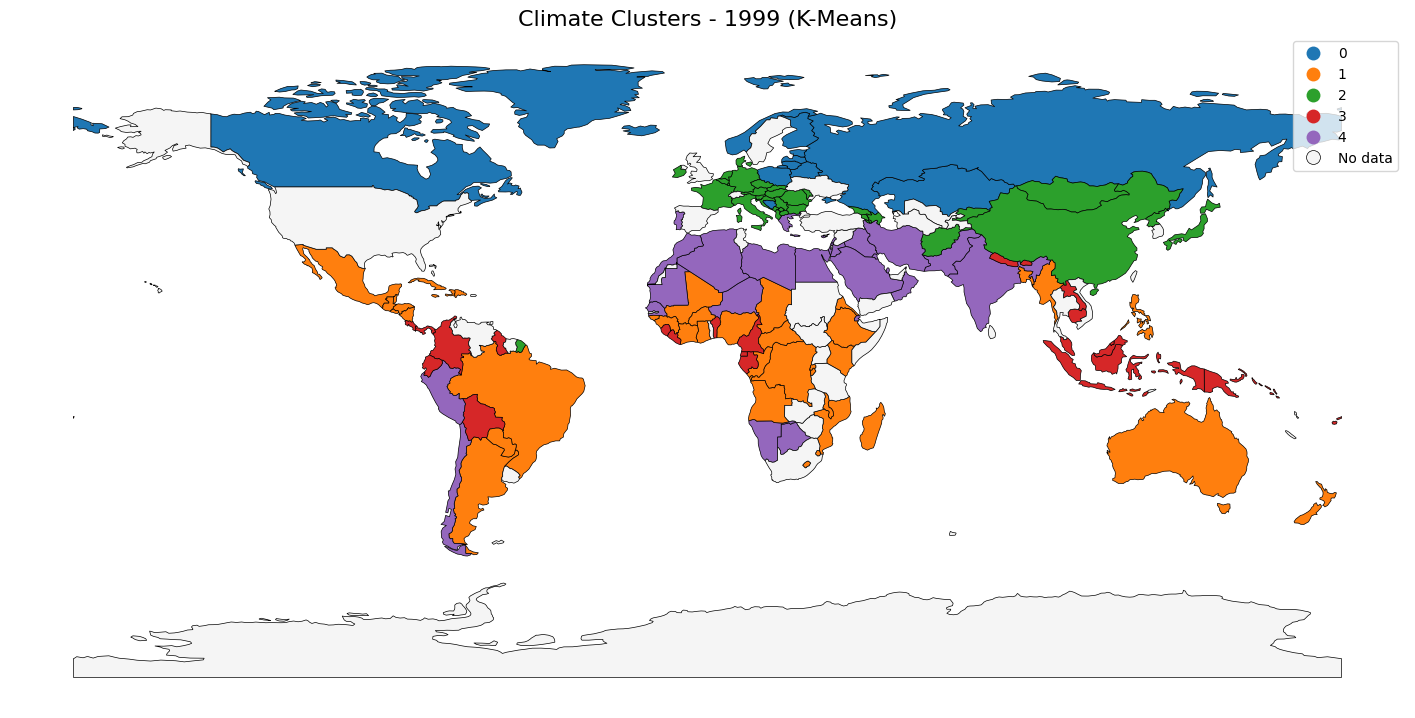

In [10]:
plot_world_year(df_clusters_anni[1999], 1999, k)

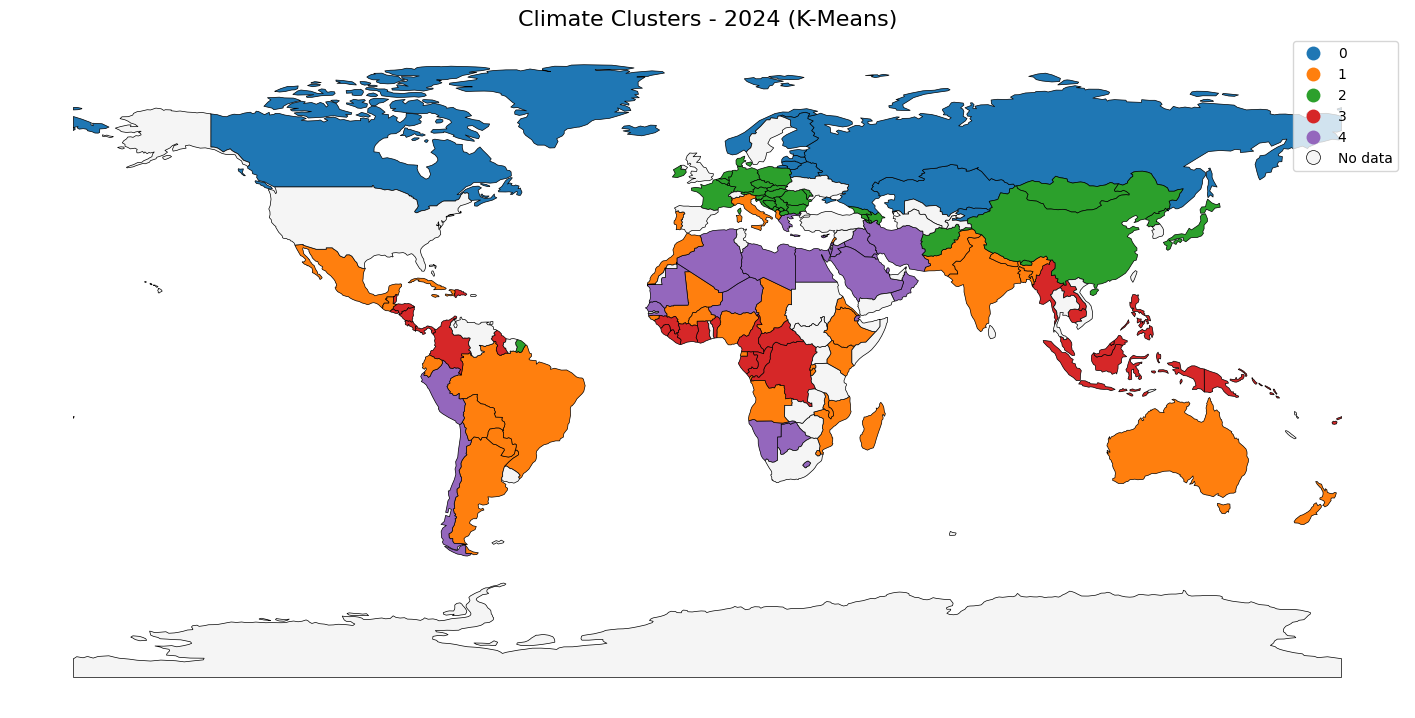

In [11]:
plot_world_year(df_clusters_anni[2024], 2024, k)

With this slider we can rapidly see the evolution of cluster assignments.

In [12]:
def plot_world_slider_go(df_clusters_anni, years, n_clusters, method="K-Means", colors_to_use=my_colors):

    colorscale = []
    for i in range(n_clusters):
        c = colors_to_use[i]
        colorscale.append([i / n_clusters, c])
        colorscale.append([(i + 1) / n_clusters, c])

    frames = []

    for year in years:
        df = df_clusters_anni[year]

        frames.append(
            go.Frame(
                data=[
                    go.Choropleth(
                        locations=df["country"],
                        locationmode="country names",
                        z=df["cluster"],
                        zmin=0,
                        zmax=n_clusters - 1,
                        colorscale=colorscale,
                        showscale=True,
                        colorbar=dict(
                            title="Cluster",
                            tickvals=list(range(n_clusters)),
                            len=0.75
                        ),
                        marker_line_color="black",
                        marker_line_width=1.2,
                                                customdata=np.stack(
                            [df["capital"], df["country"], df["cluster"]],
                            axis=-1
                        ),
                        hovertemplate=(
                            "<b>%{customdata[0]}</b><br>"
                            "<span style='font-size:12px'>%{customdata[1]}</span><br>"
                            "Cluster: %{customdata[2]}"
                            "<extra></extra>"
                        ),

                    )
                ],
                name=str(year)
            )
        )

    fig = go.Figure(
        data=frames[0].data,
        layout=go.Layout(
            title=dict(
                text=f"Climate Clusters {years[0]} - {years[-1]} ({method})",
                x=0.5,
                xanchor="center",
                font=dict(size=20)
            ),
            width=1400,
            height=750,
            geo=dict(
                domain=dict(x=[0, 1], y=[0.1, 1]),
                projection_type="natural earth",
                showframe=False,
                showcountries=True,
                countrycolor="black",
                countrywidth=1.2,
                showcoastlines=False,
                bgcolor="white"
            ),

            updatemenus=[{
                "type": "buttons",
                "showactive": False,
                "x": 0.5,
                "y": 0.03,
                "xanchor": "center",
                "direction": "left",
                "buttons": [
                    {
                        "label": "▶ Play",
                        "method": "animate",
                        "args": [
                            None,
                            {
                                "frame": {"duration": 700, "redraw": True},
                                "fromcurrent": True,
                                "transition": {"duration": 300}
                            }
                        ]
                    },
                    {
                        "label": "⏸ Pause",
                        "method": "animate",
                        "args": [
                            [None],
                            {
                                "frame": {"duration": 0, "redraw": False},
                                "mode": "immediate"
                            }
                        ]
                    }
                ]
            }],

            sliders=[{
                "y": 0.05,
                "x": 0.1,
                "len": 0.8,
                "steps": [
                    {
                        "method": "animate",
                        "label": str(year),
                        "args": [
                            [str(year)],
                            {
                                "frame": {"duration": 0, "redraw": True},
                                "mode": "immediate"
                            }
                        ]
                    }
                    for year in years
                ],
                "currentvalue": {
                    "prefix": "Year: ",
                    "font": {"size": 16}
                }
            }]
        ),
        frames=frames
    )

    fig.show()


In [13]:
years = sorted(df_clusters_anni.keys())

plot_world_slider_go(
    df_clusters_anni=df_clusters_anni,
    years=years,
    n_clusters=k,
    method="K-Means",
    colors_to_use=my_colors
)


Some boxplots to understand the distribution of clustering features.

In [14]:
def plot_boxplots(df_cluster_assignment, n_clusters, colors_to_use=my_colors):
    # 8 features → 4x2 subplot
    fig, axes = plt.subplots(4, 2, figsize=(20, 15))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        ax = axes[i]

        # Create boxplot with colors
        box_data = [df_cluster_assignment[df_cluster_assignment['cluster'].astype(int) == c][feature].values for c in range(n_clusters)]
        bp = ax.boxplot(box_data, tick_labels=range(n_clusters), patch_artist=True,
                        medianprops={'color': 'black'}, boxprops={'alpha': 0.7, 'edgecolor': 'black'})

        # Apply colors to boxes
        for patch, cluster_id in zip(bp['boxes'], range(n_clusters)):
            patch.set_facecolor(colors_to_use[cluster_id])

        # Style the plot
        ax.set_title(f'{feature} by Cluster', fontsize=12, fontweight='bold')
        ax.set_xlabel('Cluster', fontsize=10)
        ax.set_ylabel(feature, fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Feature Distribution by Cluster', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

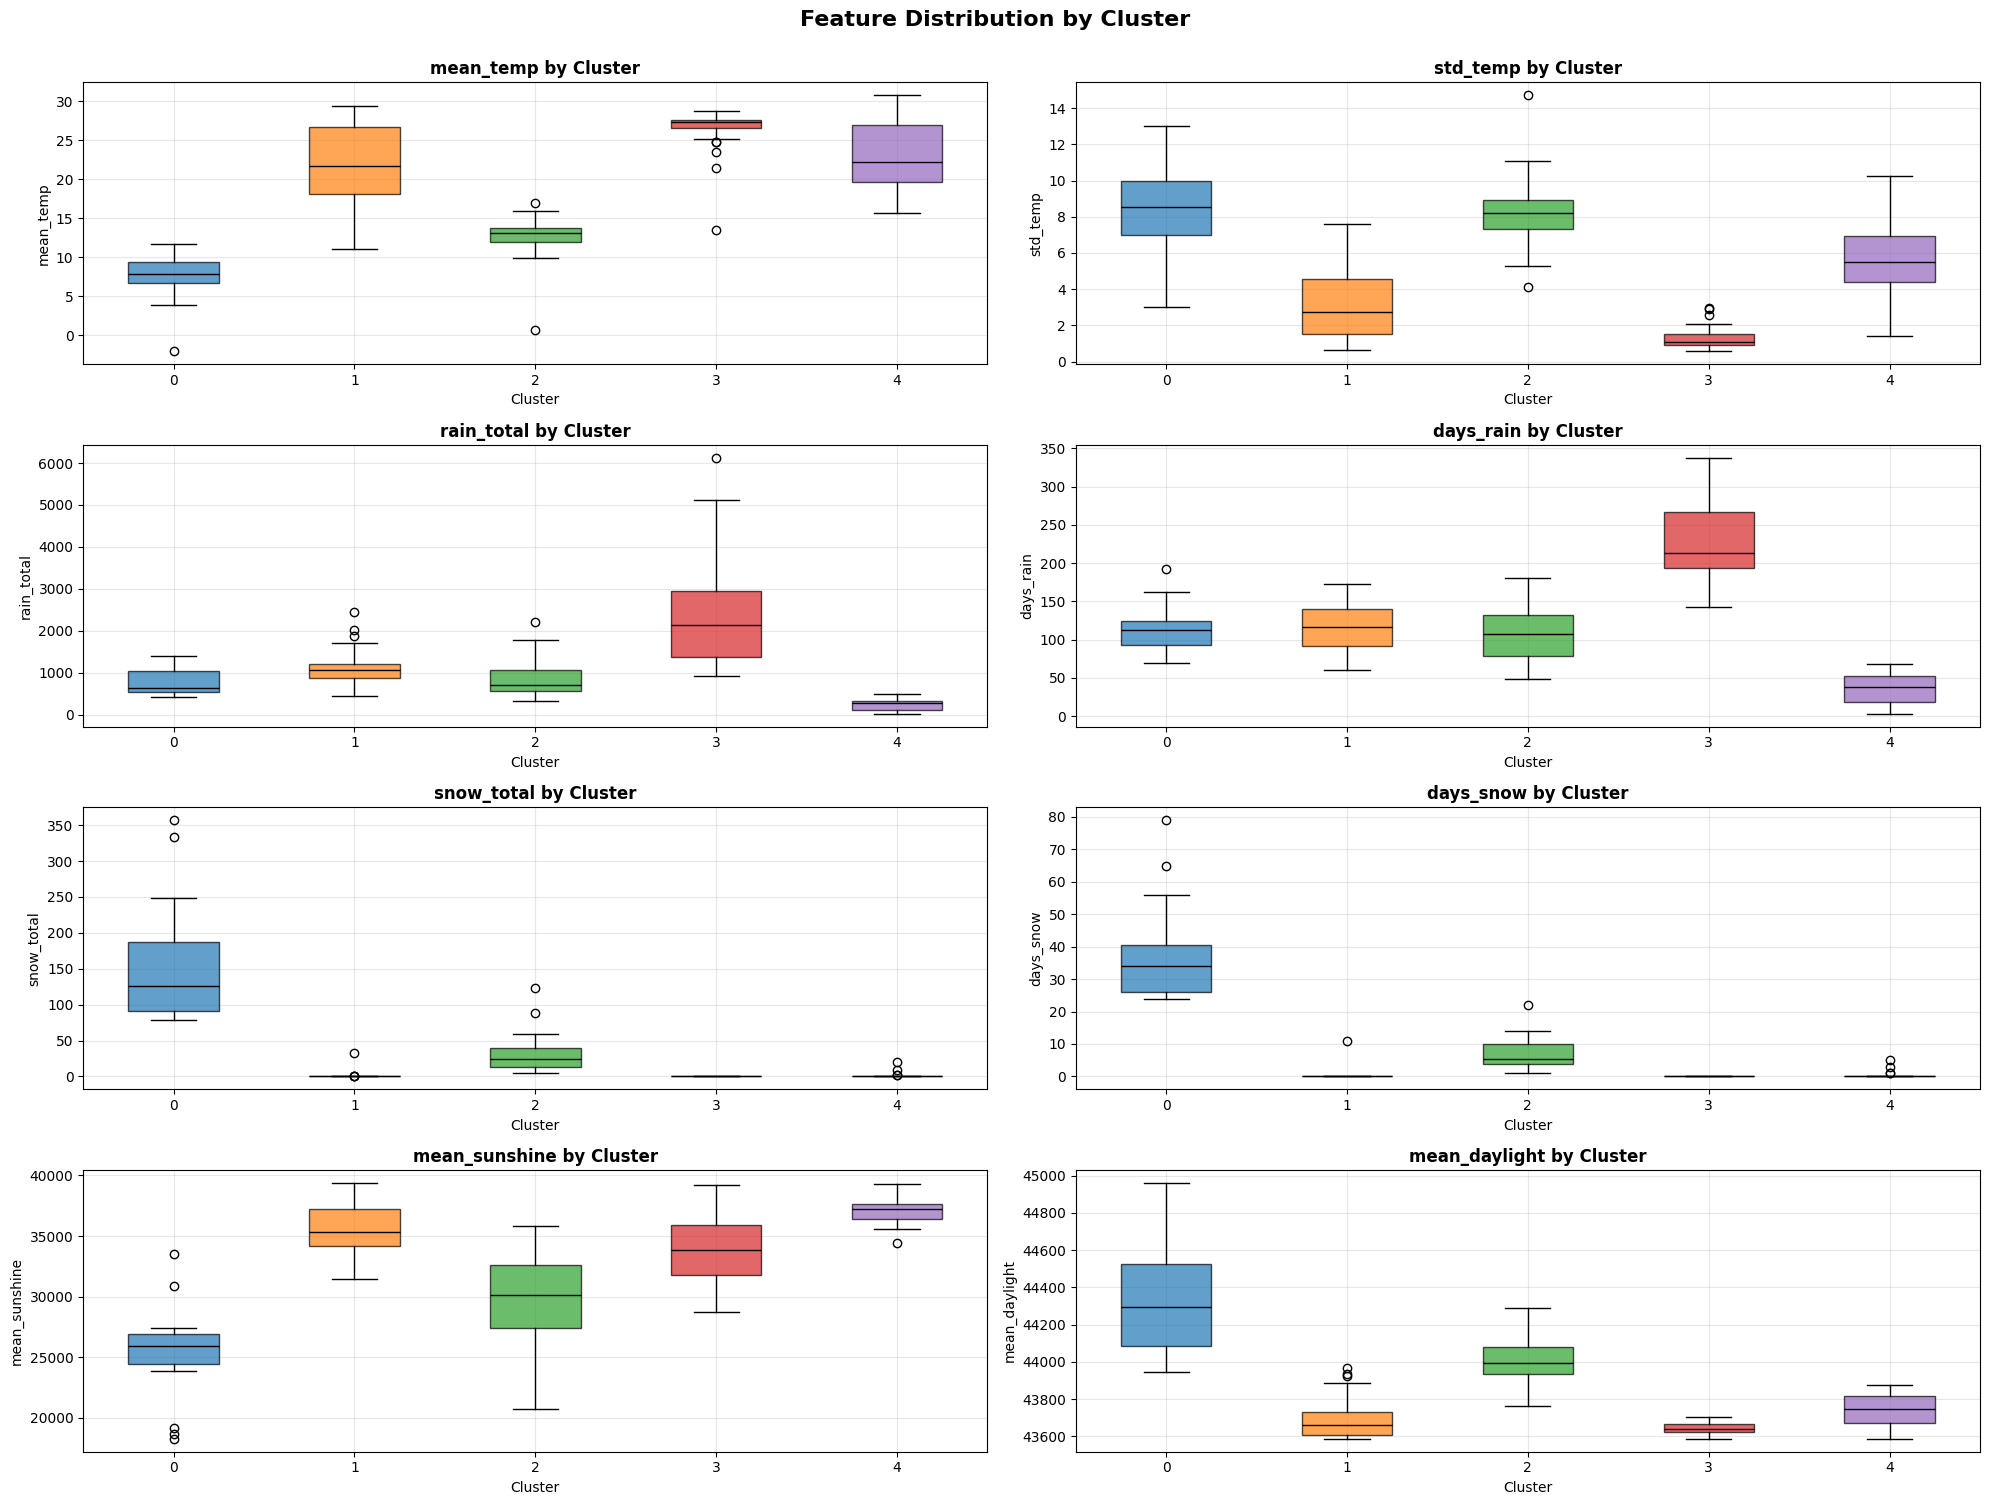

In [15]:
plot_boxplots(df_clusters_anni[2024], k)

Line charts to identify the evolution of cluster means.


EVOLUTION OF MEAN TEMPERATURES PER CLUSTER
              1995       1996       1997       1998       1999       2000  \
cluster                                                                     
0         5.706481   6.644740   5.388196   5.332397   6.140073   5.828930   
1        23.757080  23.130834  23.070052  24.502457  23.734960  22.587895   
2        10.293280  10.981402  10.170133  11.117010  11.309742  11.309567   
3        24.072953  23.443585  24.097477  23.611052  23.295200  24.376469   
4        21.227324  22.742230  21.670498  22.520455  21.883530  22.449928   

              2001       2002       2003       2004  ...       2015  \
cluster                                              ...              
0         5.688904   5.451448   5.240000   6.138277  ...   6.384468   
1        22.707444  22.545219  23.154763  20.978851  ...  24.450553   
2        10.205729  11.720479  10.942360  11.244616  ...  11.622240   
3        23.904558  24.510098  24.103908  24.749736  ...  23.

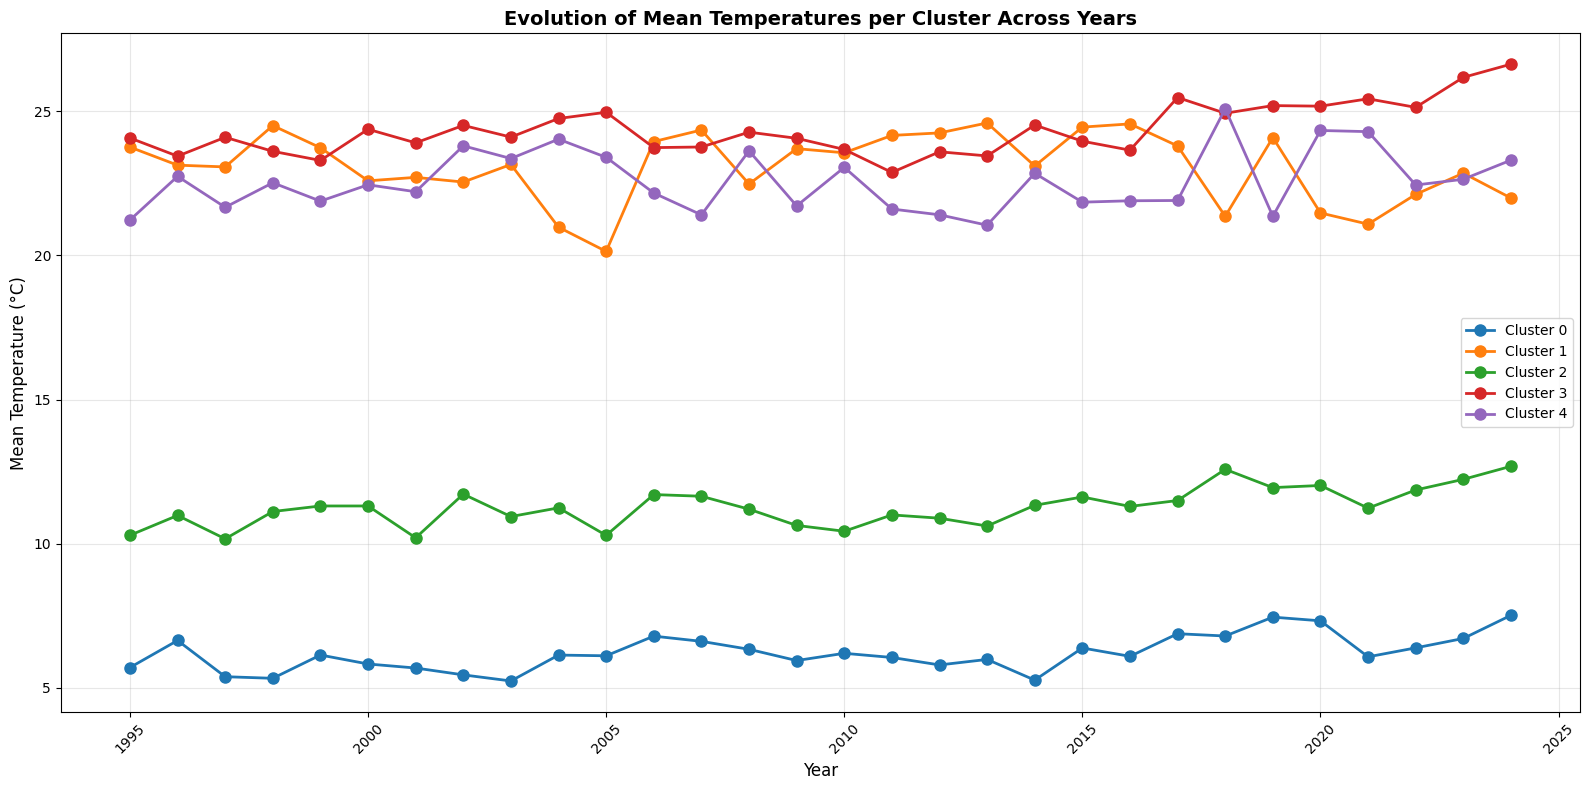


EVOLUTION OF TOTAL PRECIPITATION PER CLUSTER ACROSS YEARS
                1995         1996         1997         1998         1999  \
cluster                                                                    
0         628.646154   705.914286   588.050000   710.008333   616.633333   
1        1008.343137  1195.920312   877.756364  1109.486885  1109.114035   
2         823.742857   702.409091   757.502778   678.312500   710.752941   
3        2458.752941  2819.680000  2184.378947  2636.596000  2728.644444   
4         283.350000   241.741667   242.636364   213.652000   285.383333   

                2000         2001         2002         2003         2004  ...  \
cluster                                                                   ...   
0         686.284615   702.754545   533.235714   589.840000   674.212500  ...   
1         829.606780   816.379661   846.846154   955.706557   658.516216  ...   
2         754.594444   691.805882   903.475000   594.060000   810.594118  ...   
3  

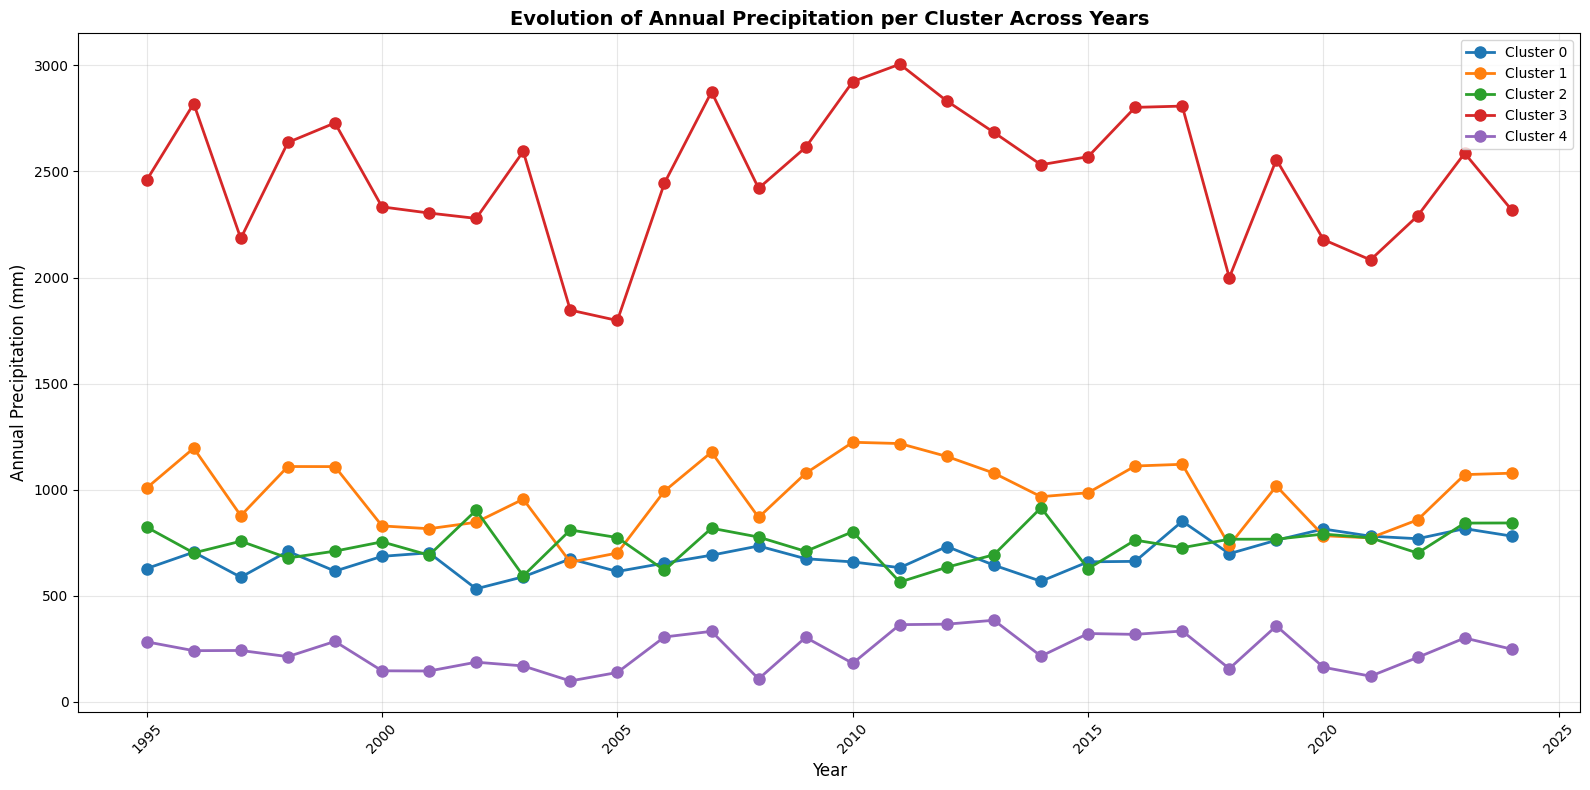

In [16]:
# Show the evolution of mean temperatures after remapping
print("\n" + "="*100)
print("EVOLUTION OF MEAN TEMPERATURES PER CLUSTER")
print("="*100)

comparison_data_remapped = {}
for year in years:
    comparison_data_remapped[year] = cluster_means_anni[year]['mean_temp']

comparison_temp_remapped = pd.DataFrame(comparison_data_remapped)
print(comparison_temp_remapped.head(30))

# Plot the evolution of temperatures after remapping
plt.figure(figsize=(16, 8))
for cluster_id in range(k):
    if cluster_id in comparison_temp_remapped.index:
        temps = comparison_temp_remapped.loc[cluster_id]
        plt.plot(years, temps, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Temperature (°C)', fontsize=12)
plt.title('Evolution of Mean Temperatures per Cluster Across Years', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Show precipitation evolution as well
print("\n" + "="*100)
print("EVOLUTION OF TOTAL PRECIPITATION PER CLUSTER ACROSS YEARS")
print("="*100)

comparison_rain_remapped = {}
for year in years:
    comparison_rain_remapped[year] = cluster_means_anni[year]['rain_total']

comparison_rain_df = pd.DataFrame(comparison_rain_remapped)
print(comparison_rain_df)

# Plot the evolution of precipitation after remapping
plt.figure(figsize=(16, 8))
for cluster_id in range(k):
    if cluster_id in comparison_rain_df.index:
        precips = comparison_rain_df.loc[cluster_id]
        plt.plot(years, precips, marker='o', label=f'Cluster {cluster_id}', linewidth=2, markersize=8)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Annual Precipitation (mm)', fontsize=12)
plt.title('Evolution of Annual Precipitation per Cluster Across Years', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sankey diagram to show interactively how capitals move between clusters

In [17]:
def plot_cluster_flow_sankey(df_clusters_dict, years):
    """
    Creates a Sankey diagram showing how capitals move between clusters
    """
    # Analyze flows between consecutive years
    for i in range(len(years) - 1):
        t1 = years[i]
        t2 = years[i + 1]

        df1 = df_clusters_dict[t1][['capital', 'cluster']]
        df2 = df_clusters_dict[t2][['capital', 'cluster']]

        # Merge to find movements
        flows = df1.merge(df2, on='capital', suffixes=('_from', '_to'))

        # Count the flows
        flow_counts = flows.groupby(['cluster_from', 'cluster_to']).size().reset_index(name='count')

        # Prepare data for Sankey
        sources = []
        targets = []
        values = []

        for _, row in flow_counts.iterrows():
            sources.append(int(row['cluster_from']))
            targets.append(int(row['cluster_to']) + k)  # Offset to distinguish targets from sources
            values.append(row['count'])

        # Create labels
        labels = [f"Cluster {i} ({t1})" for i in range(k)] + [f"Cluster {i} ({t2})" for i in range(k)]

        # Plot
        fig = go.Figure(data=[go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=labels
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )])

        fig.update_layout(
            title_text=f"Capital Flow Between Clusters: {t1} → {t2}",
            font_size=12,
            height=600
        )
        fig.show()

In [18]:
#Avoided to reduce size of the colab - it plots every change year to year
#plot_cluster_flow_sankey(df_clusters_anni, years)

In [19]:
def plot_cluster_flow_sankey_first_to_last(df_clusters_dict, years):
    """
    Creates a Sankey diagram showing how capitals move between clusters
    from the first to the last year
    """

    first_year = years[0]
    last_year = years[-1]

    print(f"Creating Sankey: {first_year} → {last_year}")

    df1 = df_clusters_dict[first_year][['capital', 'cluster']]
    df2 = df_clusters_dict[last_year][['capital', 'cluster']]

    # Merge to find movements
    flows = df1.merge(df2, on='capital', suffixes=('_from', '_to'))

    # Count the flows
    flow_counts = flows.groupby(['cluster_from', 'cluster_to']).size().reset_index(name='count')

    # Print statistics
    print(f"\nFlow statistics:")
    print(f"Total capitals tracked: {len(flows)}")
    print(f"\nTransition matrix:")
    transition_matrix = flows.groupby(['cluster_from', 'cluster_to']).size().unstack(fill_value=0)
    print(transition_matrix)

    # Calculate stability per cluster
    print(f"\nCluster stability (% remaining in the same cluster):")
    for cluster_id in range(k):
        mask_same = (flows['cluster_from'].astype(int) == cluster_id) & (flows['cluster_to'].astype(int) == cluster_id)
        mask_total = (flows['cluster_from'].astype(int) == cluster_id)

        same_cluster = len(flows[mask_same])
        total_in_cluster = len(flows[mask_total])
        if total_in_cluster > 0:
            stability = (same_cluster / total_in_cluster) * 100
            print(f"  Cluster {cluster_id}: {stability:.1f}% ({same_cluster}/{total_in_cluster})")

    # Prepare data for Sankey
    sources = []
    targets = []
    values = []
    colors = []

    # Colors for the links
    link_colors = {
        'stable': 'rgba(0, 128, 0, 0.4)',      # Green for those who stay
        'change': 'rgba(255, 165, 0, 0.3)'     # Orange for those who change
    }

    for _, row in flow_counts.iterrows():
        sources.append(int(row['cluster_from']))
        targets.append(int(row['cluster_to']) + k)  # Offset to distinguish targets from sources
        values.append(row['count'])

        # Color those remaining in the same cluster differently
        if row['cluster_from'] == row['cluster_to']:
            colors.append(link_colors['stable'])
        else:
            colors.append(link_colors['change'])

    # Create labels
    labels = [f"Cluster {i}\n({first_year})" for i in range(k)] + \
             [f"Cluster {i}\n({last_year})" for i in range(k)]

    # Colors for the nodes
    node_colors = [my_colors[i] for i in range(k)] + [my_colors[i] for i in range(k)]

    # Plot
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=1),
            label=labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors
        )
    )])

    fig.update_layout(
        title_text=f"Capital Flow Between Clusters: {first_year} → {last_year}<br>" +
                   f"<sub>Green = stays in same cluster | Orange = changes cluster</sub>",
        font_size=14,
        height=700,
        width=1200
    )

    fig.show()

    return flows


In [20]:
# Create the diagram and save the flows
flows_first_last = plot_cluster_flow_sankey_first_to_last(df_clusters_anni, years)

Creating Sankey: 1995 → 2024

Flow statistics:
Total capitals tracked: 163

Transition matrix:
cluster_to     0   1   2   3   4
cluster_from                    
0             12   0   1   0   0
1              0  28   0  21   2
2              3   2  30   0   0
3              0   8   0  26   0
4              0   6   1   0  23

Cluster stability (% remaining in the same cluster):
  Cluster 0: 92.3% (12/13)
  Cluster 1: 54.9% (28/51)
  Cluster 2: 85.7% (30/35)
  Cluster 3: 76.5% (26/34)
  Cluster 4: 76.7% (23/30)


Statistical analysis of the variations

In [22]:
def analyze_cluster_statistics_no_plots(df_clusters_dict, cluster_means_dict, years_compare, features_analyze):
    """
    Analyzes cluster statistics for specific years
    Shows only statistical tables (NO PLOTS)
    """

    print("\n" + "="*100)
    print(f"CLUSTER STATISTICAL ANALYSIS: {years_compare[0]} vs {years_compare[1]}")
    print("="*100)

    # Prepare data for both years
    data_comparison = {}

    for year in years_compare:
        print(f"\n{'-'*100}")
        print(f"YEAR {year}")
        print(f"{'-'*100}")

        cluster_stats = cluster_means_dict[year][features_analyze].copy()

        print(cluster_stats.round(2))
        print(f"\nCapital distribution per cluster:")
        print(df_clusters_dict[year]['cluster'].value_counts().sort_index())

        data_comparison[year] = cluster_stats

    # Calculate absolute variations
    print(f"\n{'='*100}")
    print(f"ABSOLUTE VARIATIONS ({years_compare[1]} - {years_compare[0]})")
    print(f"{'='*100}")

    variation_absolute = data_comparison[years_compare[1]] - data_comparison[years_compare[0]]
    print(variation_absolute.round(2))

    # Calculate percentage variations
    print(f"\n{'='*100}")
    print(f"PERCENTAGE VARIATIONS ({years_compare[1]} - {years_compare[0]}) / {years_compare[0]} * 100 (%)")
    print(f"{'='*100}")

    variation_percent = ((data_comparison[years_compare[1]] - data_comparison[years_compare[0]]) /
                         data_comparison[years_compare[0]] * 100).replace([np.inf, -np.inf], np.nan)
    print(variation_percent.round(2))

    # Summary table per feature
    print(f"\n{'='*100}")
    print("SUMMARY PER FEATURE")
    print(f"{'='*100}")

    for feature in features_analyze:
        print(f"\n{feature.upper()}")
        print(f"{'-'*80}")

        summary_df = pd.DataFrame({
            f'{years_compare[0]}': data_comparison[years_compare[0]][feature],
            f'{years_compare[1]}': data_comparison[years_compare[1]][feature],
            'Difference': variation_absolute[feature],
            '% Variation': variation_percent[feature]
        })

        print(summary_df.round(2))

    return data_comparison, variation_absolute, variation_percent

In [23]:
# Run the analysis
features_to_analyze = ['mean_temp', 'rain_total', 'snow_total']
years_to_compare = [1995, 2024]

comparison_data, variation_abs, variation_pct = analyze_cluster_statistics_no_plots(
    df_clusters_anni,
    cluster_means_anni,
    years_to_compare,
    features_to_analyze
)


CLUSTER STATISTICAL ANALYSIS: 1995 vs 2024

----------------------------------------------------------------------------------------------------
YEAR 1995
----------------------------------------------------------------------------------------------------
         mean_temp  rain_total  snow_total
cluster                                   
0             5.71      628.65      150.70
1            23.76     1008.34        0.00
2            10.29      823.74       59.45
3            24.07     2458.75        0.61
4            21.23      283.35        0.49

Capital distribution per cluster:
cluster
0    13
1    51
2    35
3    34
4    30
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------
YEAR 2024
----------------------------------------------------------------------------------------------------
         mean_temp  rain_total  snow_total
cluster                                   
0             7.52      781.54    

Static heatmap representing evolution capital by capital.

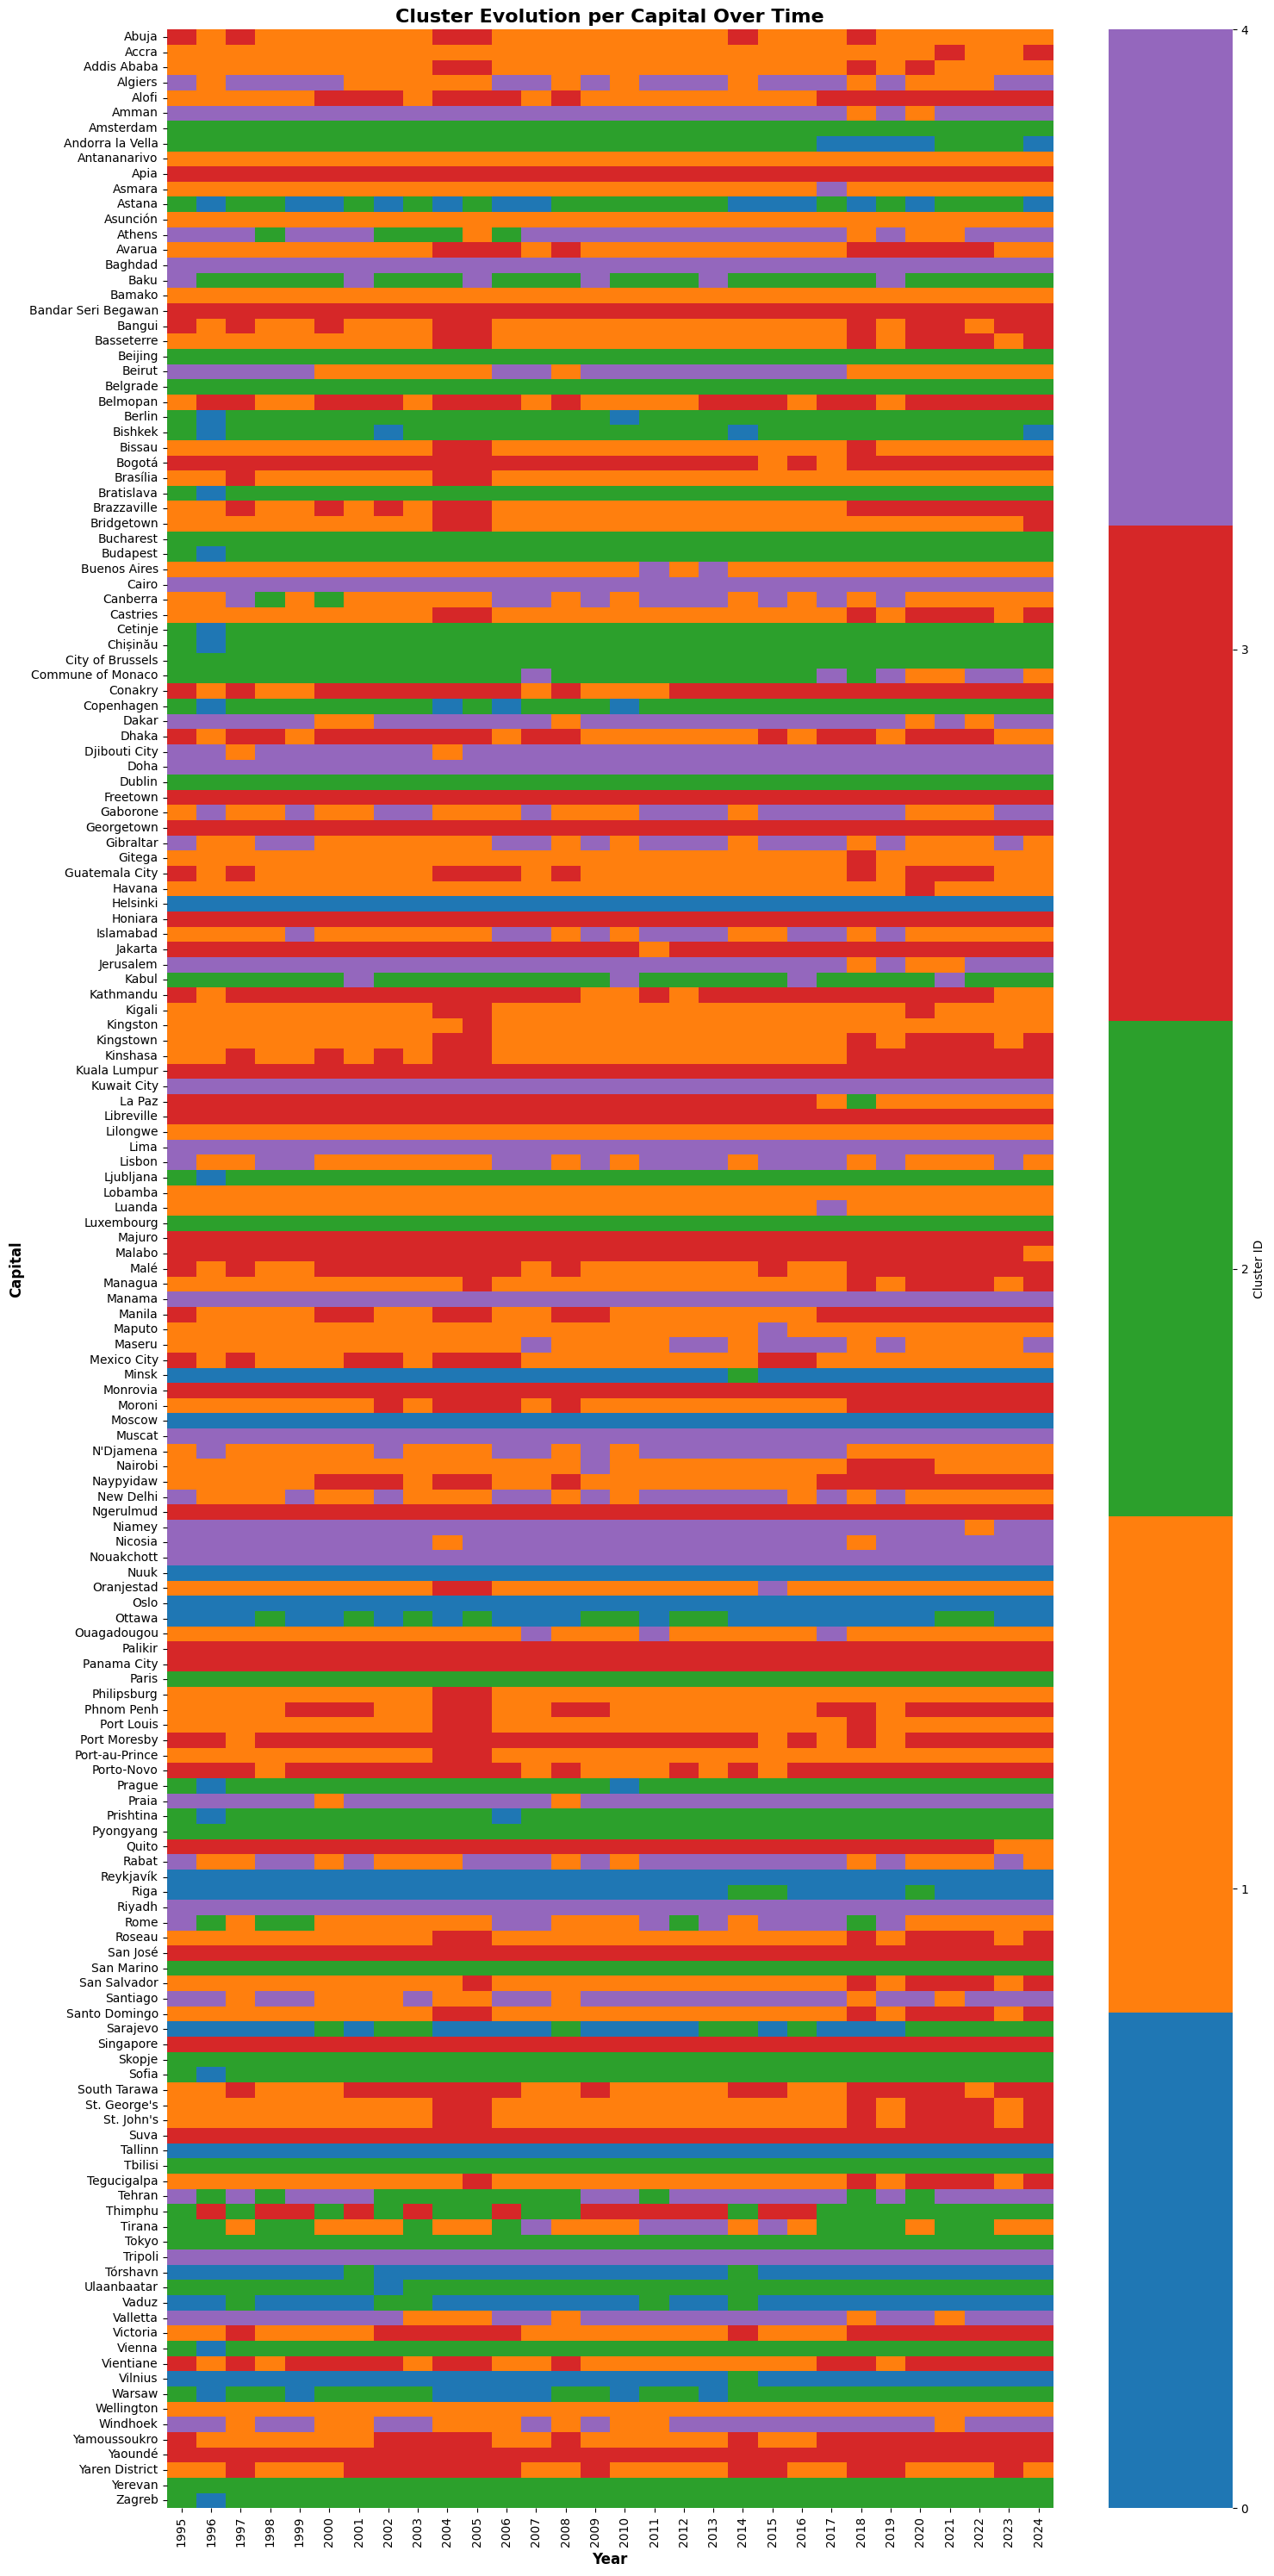

In [24]:
# --- STEP 1: Combine the dictionary of dataframes into one ---
df_combined = pd.concat(df_clusters_anni.values(), ignore_index=True)

# Force the cluster column to be numeric to avoid the TypeError
df_combined['cluster'] = pd.to_numeric(df_combined['cluster'])

# --- STEP 2: Create the Matrix ---
# Index = Capital, Columns = Year, Values = Cluster
heatmap_data = df_combined.pivot(index='capital', columns='year', values='cluster')

# --- STEP 3: Visualization ---
plt.figure(figsize=(15, 30))

n_clusters = df_combined['cluster'].nunique()
cmap = sns.color_palette("tab10", n_clusters)

sns.heatmap(
    heatmap_data,
    cmap=cmap,
    cbar_kws={'ticks': range(n_clusters), 'label': 'Cluster ID'},
    yticklabels=True
)

plt.title('Cluster Evolution per Capital Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Capital', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# PCA visualization

As in previous notebook, PCA helps visualizing the robustness and consitency of clustering.

In [25]:
def plot_PCA(
    df_cluster_assignment,
    year,
    colors_to_use=my_colors,
    capitals=[
        'Rome', 'Ottawa', 'Tokyo', 'Moscow', 'Mexico City',
        'Windhoek', 'Berlin', 'Luanda', 'Jakarta', 'Lima',
        'Santiago', 'Canberra', 'New Delhi', 'Algiers'
    ]
):

    # ===============================
    # 1. Filter year
    # ===============================
    df_year = df_cluster_assignment[df_cluster_assignment['year'] == year].copy()

    # ===============================
    # 2. Numerical columns
    # ===============================
    numerical_cols = df_year.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [c for c in numerical_cols if c not in ['year', 'cluster']]

    print(f"Numerical columns found: {numerical_cols}")

    # ===============================
    # 3. PCA
    # ===============================
    df_numeric = df_year[numerical_cols].dropna()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_numeric)

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # ===============================
    # 4. CORRECT assignment
    # ===============================
    df_year.loc[df_numeric.index, 'pca1'] = pca_result[:, 0]
    df_year.loc[df_numeric.index, 'pca2'] = pca_result[:, 1]

    # ===============================
    # 6. Variance info
    # ===============================
    print("\nExplained variance:")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.1%}")
    print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")

    # ===============================
    # 7. Plot
    # ===============================
    plt.figure(figsize=(14, 10))

    for cluster_id in sorted(df_year['cluster'].unique()):
        cluster_data = df_year[df_year['cluster'] == cluster_id]

        plt.scatter(
            cluster_data['pca1'],
            cluster_data['pca2'],
            c=colors_to_use[cluster_id],
            label=f'Cluster {cluster_id}',
            alpha=0.7,
            s=120,
            edgecolors='black',
            linewidth=0.8
        )

    # Capital labels
    for capital in capitals:
        row = df_year[df_year["capital"] == capital]
        if not row.empty:
            plt.annotate(
                capital,
                (row['pca1'].values[0], row['pca2'].values[0]),
                fontsize=9,
                alpha=0.9,
                fontweight='bold'
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
               fontsize=12, fontweight='bold')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
               fontsize=12, fontweight='bold')
    plt.title(f'PCA Projection of Climate Clusters - {year}',
              fontsize=14, fontweight='bold')

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Numerical columns found: ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine', 'lat', 'lon']

Explained variance:
PC1: 53.1%
PC2: 20.1%
Total: 73.2%


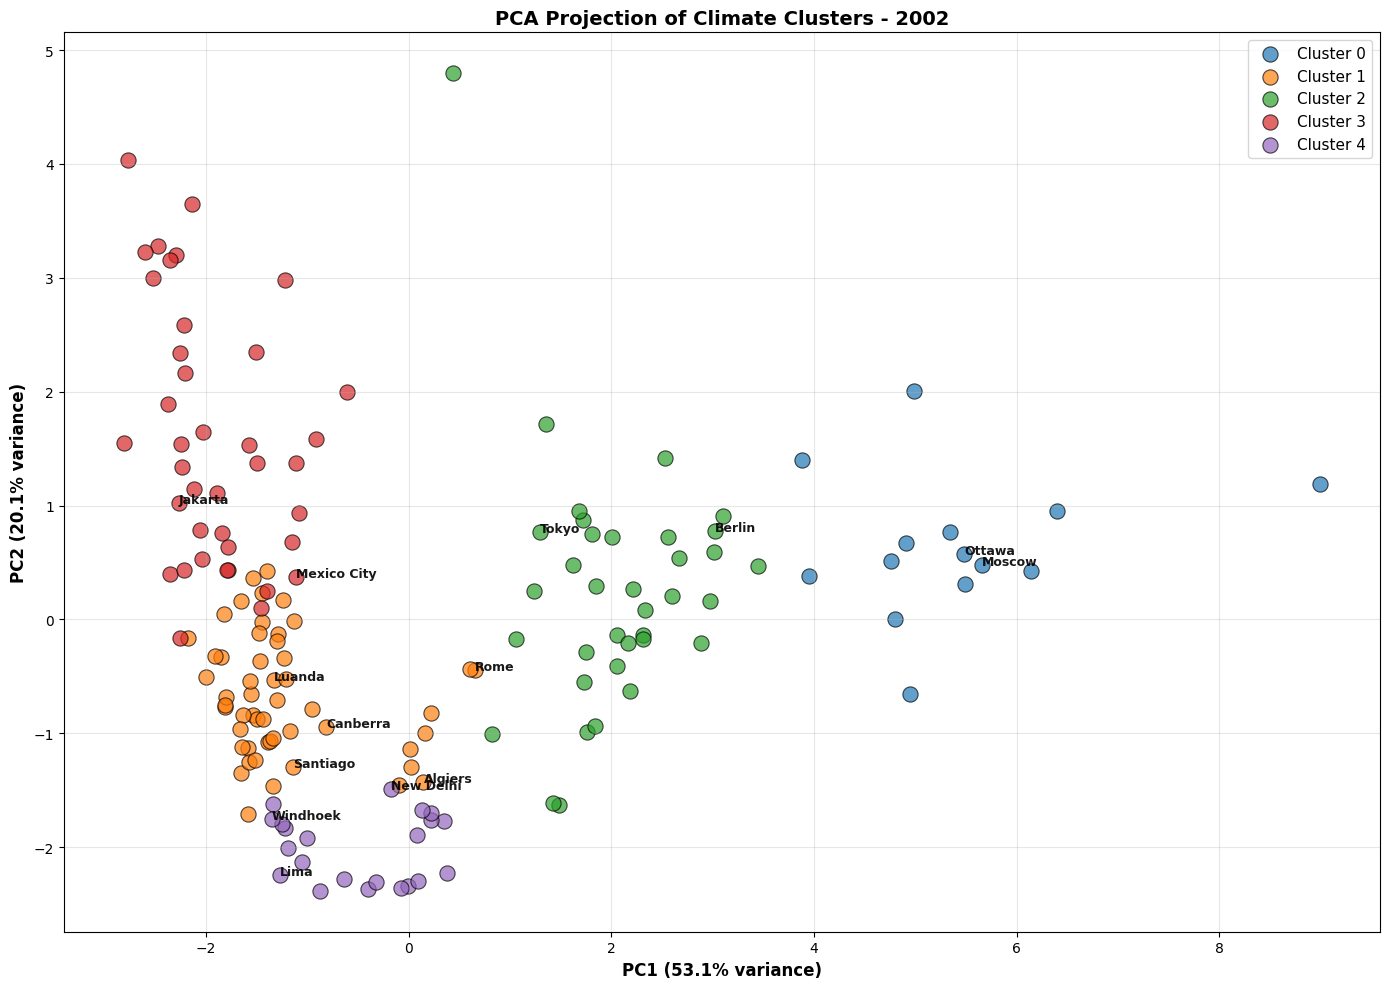

Numerical columns found: ['mean_temp', 'std_temp', 'rain_total', 'days_rain', 'snow_total', 'days_snow', 'mean_daylight', 'mean_sunshine', 'lat', 'lon']

Explained variance:
PC1: 54.6%
PC2: 19.3%
Total: 74.0%


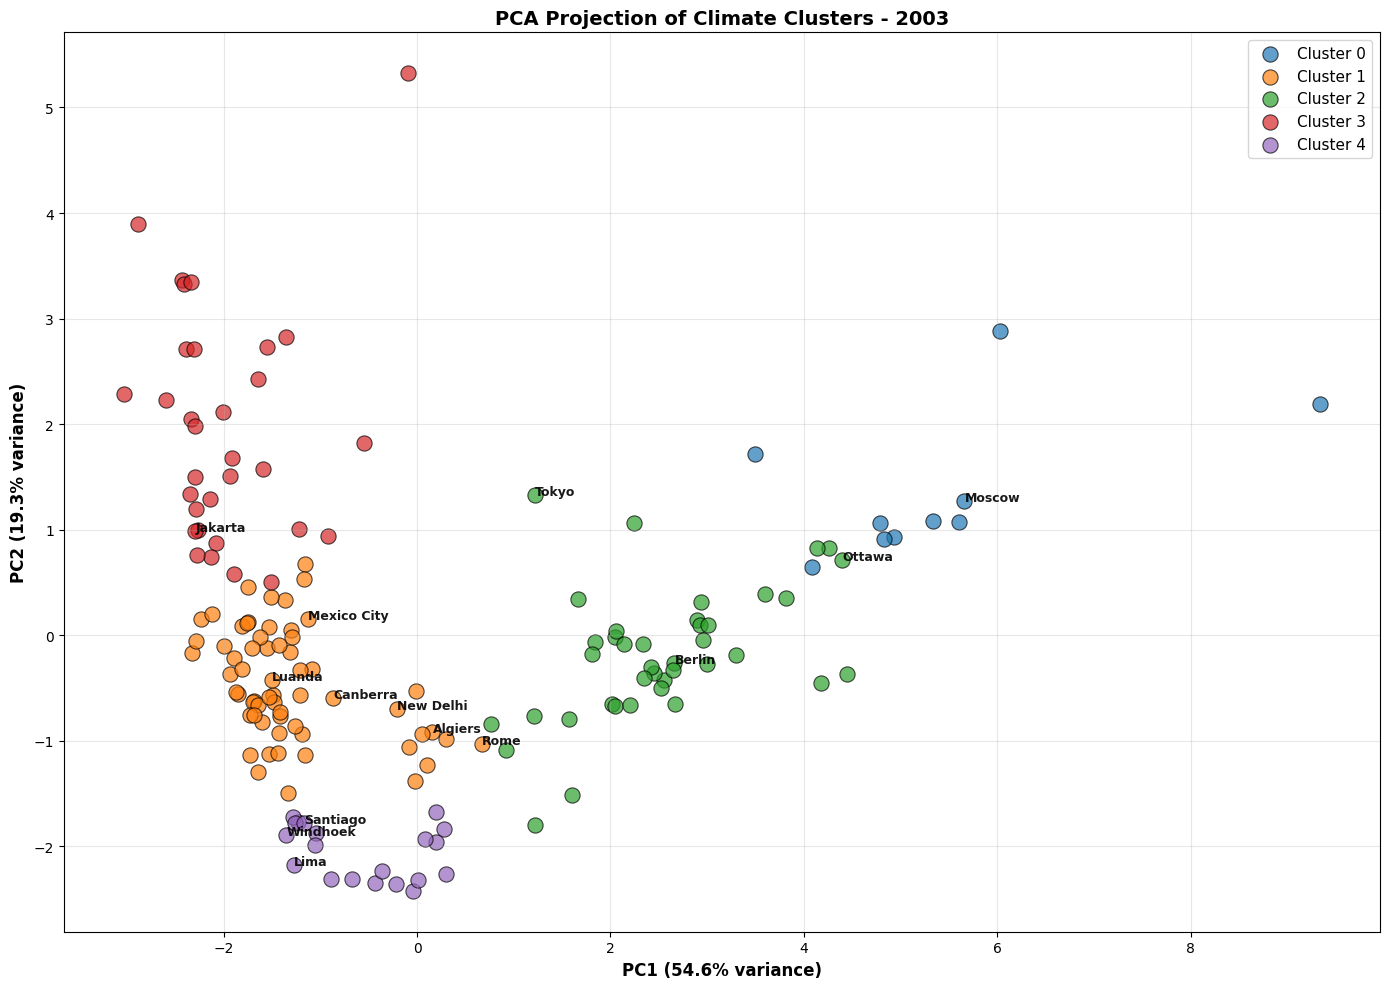

In [26]:
plot_PCA(df_clusters_anni[2002], 2002)
plot_PCA(df_clusters_anni[2003], 2003)

In [27]:
def plot_PCA_interactive(
    df_cluster_assignment,
    colors_to_use=my_colors,
    capitals=[
        'Rome', 'Ottawa', 'Tokyo', 'Moscow', 'Mexico City',
        'Windhoek', 'Berlin', 'Luanda', 'Jakarta', 'Lima',
        'Santiago', 'Canberra', 'New Delhi', 'Algiers'
    ]
):
    # ===============================
    # 1. Prepare Data & Numerical Columns
    # ===============================
    numerical_cols = df_cluster_assignment.select_dtypes(include=[np.number]).columns.tolist()
    numerical_cols = [c for c in numerical_cols if c not in ['year', 'cluster']]

    print(f"Numerical columns found: {numerical_cols}")

    # Drop NaNs to avoid PCA errors
    df_clean = df_cluster_assignment.dropna(subset=numerical_cols).copy()

    # Sort by year ascending (Crucial for the slider to play in the right order)
    df_clean = df_clean.sort_values(by='year')

    # ===============================
    # 2. GLOBAL PCA (Fitted on all years for smooth animation)
    # ===============================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clean[numerical_cols])

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # Assign coordinates back
    df_clean['pca1'] = pca_result[:, 0]
    df_clean['pca2'] = pca_result[:, 1]

    print("\nGlobal Explained variance:")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.1%}")
    print(f"Total: {pca.explained_variance_ratio_.sum():.1%}")

    # ===============================
    # 3. Prepare Plotly Features
    # ===============================
    # Create an annotation column: only show names for the selected capitals
    df_clean['label'] = df_clean['capital'].apply(lambda x: x if x in capitals else "")

    # Plotly needs categories as strings to assign discrete colors correctly
    df_clean['cluster_str'] = df_clean['cluster'].astype(str)

    # Format the color mapping dictionary if colors_to_use is a list
    if isinstance(colors_to_use, list):
        color_map = {str(i): colors_to_use[i] for i in range(len(colors_to_use))}
    else:
        color_map = colors_to_use # Assuming it's already a dict

    # ===============================
    # 4. Plotly Interactive Animation
    # ===============================
    fig = px.scatter(
        df_clean,
        x='pca1',
        y='pca2',
        animation_frame='year',       # Creates the slider
        animation_group='capital',    # Tells Plotly how to connect the dots across years
        color='cluster_str',
        hover_name='capital',         # Shows the capital name when you hover over ANY dot
        text='label',                 # Permanently displays text for the selected capitals
        color_discrete_map=color_map,
        title='Interactive PCA Projection of Climate Clusters Over Time',
        labels={
            'pca1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
            'pca2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
            'cluster_str': 'Cluster'
        }
    )

    # Styling adjustments
    fig.update_traces(
        textposition='top center',
        textfont=dict(size=10, color='black'),
        marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey'))
    )

    # Lock the axis ranges so the box doesn't resize during the animation
    fig.update_layout(
        xaxis=dict(range=[df_clean['pca1'].min() - 1, df_clean['pca1'].min() + 1]),
        yaxis=dict(range=[df_clean['pca2'].min() - 1, df_clean['pca2'].min() + 1]),
        height=700,
        width=1000,
        template='plotly_white',
        title_font=dict(size=20),
        legend_title_text='Cluster'
    )

    # Auto-adjust the axis ranges nicely based on the min/max of the global data
    fig.update_xaxes(range=[df_clean['pca1'].min() - 1, df_clean['pca1'].max() + 1])
    fig.update_yaxes(range=[df_clean['pca2'].min() - 1, df_clean['pca2'].max() + 1])

    fig.show()

In [ ]:
#plot_PCA_interactive(df_combined, colors_to_use=my_colors)

# Conclusion

1. **Consistency with climatic profiles**: the climate zones identified in the previous notebooks remain consistent throughout the yearly analysis. Climate clusters do not undergo abrupt transformations but evolve gradually over time, preserving their overall structure and the assignment of capitals to specific climate regimes.

2. **Statistical evolution**: temperatures exhibit a gradual year-by-year increase, consistent with the trends observed during the EDA phase. Precipitation patterns display higher inter-annual variability. These variations are influenced both by broader global climate changes and by shifts in cluster composition, as specific climate events occurring in individual capitals can significantly affect the statistical properties of the belonging cluster.

3. **Stability and transitions in capital clustering**: most capitals consistently remain assigned to the same cluster over time, acting as climatic anchors for their respective groups (e.g., Zagreb, Nuuk, Kuala Lumpur, Riyadh). Conversely, capitals located in climatic transition zones experience more frequent changes in cluster membership (e.g., Rome, Astana, Rabat, Kinshasa). Cluster transitions rarely occur between distant climatic regimes; instead, changes typically involve neighbouring clusters, such as transitions between clusters 1↔3, 2↔0 or 1↔4.